In [25]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense
from IPython.display import display,Markdown, Latex
from sklearn.datasets import make_blobs
from matplotlib.widgets import Slider
from lab_utils_common import dlc
from lab_utils_softmax import plt_softmax
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)


In [26]:
def my_softmax(z):
    ez=np.exp(z)
    sm=ez/np.sum(ez)
    return sm

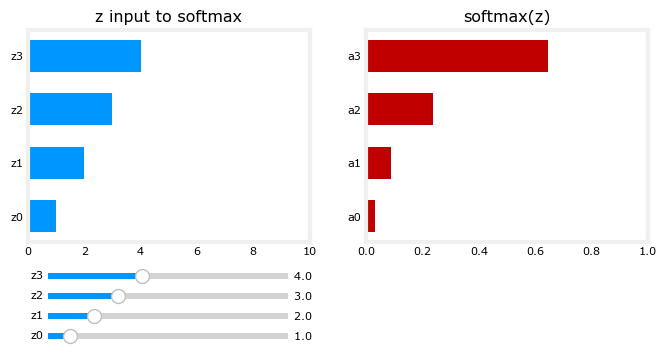

In [27]:
plt.close('all')
plt_softmax(my_softmax)

In [28]:
'''
make_blobs generates isotropic Gaussian clusters (blobs) in feature space.
In simple terms:
It creates points grouped around cluster centers
Each group corresponds to one class / cluster
Labels are generated automatically
'''


centers=[[-5,2],[-2,-2],[1,2],[5,-2]]
X_train,y_train=make_blobs(n_samples=2000,centers=centers,cluster_std=1.0,random_state=30)
print(X_train)
print(y_train)

'''
y_label={0,1,2,3,...,(number of centers-1)}
so here centers=4
y belong to (0,1,2,3)
'''

[[ 1.56  0.85]
 [-5.34  1.03]
 [-4.09  0.68]
 ...
 [-0.84 -1.95]
 [ 5.04 -2.92]
 [ 0.38  1.5 ]]
[2 0 0 ... 1 3 2]


'\ny_label={0,1,2,3,...,(number of centers-1)}\nso here centers=4\ny belong to (0,1,2,3)\n'

In [29]:
# non preferred method of implementing softmax

model=Sequential([
    Dense(units=25,activation='relu'),
    Dense(units=15,activation='relu'),
    Dense(units=4,activation='softmax')
])

model.compile(loss=keras.losses.SparseCategoricalCrossentropy(),
              optimizer=keras.optimizers.Adam(0.001))

model.fit(X_train,y_train,epochs=10)


p_nonpreferred=model.predict(X_train)
print(p_nonpreferred[:2])
print("largest value", np.max(p_nonpreferred), "smallest value", np.min(p_nonpreferred))

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 993us/step - loss: 0.9633 
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3108  
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 976us/step - loss: 0.1469
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0932  
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0698  
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0584  
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0510  
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0457  
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 920us/step - loss: 0.0420
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0390  
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
[[4.66e-03 9.40e-03 9.79e-01 6.93e-03]
 [9.95e-01 4.62e-03 1.98e-05 1.02e-05]]
largest value 0.99999964 smallest value 3.860985e-09


In [30]:
# preferred way of implementing softmax

preferred_model=Sequential([
    Dense(units=25,activation='relu'),
    Dense(units=15,activation='relu'),
    Dense(units=4,activation='linear')
])

preferred_model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=keras.optimizers.Adam(0.001),
)
preferred_model.fit(X_train,y_train,epochs=10)

p_preferred=preferred_model.predict(X_train)
print(f"two example output vectors:\n {p_preferred[:2]}")
print("largest value", np.max(p_preferred), "smallest value", np.min(p_preferred))

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 919us/step - loss: 0.7647 
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 937us/step - loss: 0.2932
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 960us/step - loss: 0.1350
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 988us/step - loss: 0.0845
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1000us/step - loss: 0.0646
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 920us/step - loss: 0.0548
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 944us/step - loss: 0.0481
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 960us/step - loss: 0.0432
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 928us/step - loss: 0.0396
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 926us/step - loss: 0.0361
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 925us/step
two example output vectors:
 [[-2.21 -1.87  3.76 -1.01]
 [ 7.36  1.52 -2.65 -6.81]]
largest value 12.546196 smallest value -12.50262


In [31]:
'''
the above
The output predictions are not probabilities! If the desired output are probabilities, the output should be be processed by a softmax.
'''

sm_preferred=tf.nn.softmax(p_preferred).numpy()
print(f"two example output vectors:\n {sm_preferred[:2]}")
print("largest value", np.max(sm_preferred), "smallest value", np.min(sm_preferred))

two example output vectors:
 [[2.51e-03 3.56e-03 9.86e-01 8.38e-03]
 [9.97e-01 2.92e-03 4.48e-05 7.01e-07]]
largest value 0.99999905 smallest value 2.2771566e-11


In [ ]:
'''  
To select the most likely category, the softmax is not required. One can find the index of the largest output using np.argmax().

The argmax method is used to find the index (position) of the maximum value in an array. It is fundamental in classification, especially when working with softmax outputs.
'''
for i in range(5):
    print(f'{p_preferred[i]}, category: {np.argmax(p_preferred[i])}')

[-2.21 -1.87  3.76 -1.01], category: 2
[ 7.36  1.52 -2.65 -6.81], category: 0
[ 5.33  1.7  -1.96 -5.33], category: 0
[-0.58  4.84 -0.58 -1.83], category: 1
[-0.23 -3.65  5.16 -4.53], category: 2


In [ ]:
## SparseCategorialCrossentropy or CategoricalCrossEntropy
# Tensorflow has two potential formats for target values and the selection of the loss defines which is expected.
# - SparseCategorialCrossentropy: expects the target to be an integer corresponding to the index. For example, if there are 10 potential target values, y would be between 0 and 9. 
# - CategoricalCrossEntropy: Expects the target value of an example to be one-hot encoded where the value at the target index is 1 while the other N-1 entries are zero. An example with 10 potential target values, where the target is 2 would be [0,0,1,0,0,0,0,0,0,0].